# The pipeline on four datasets

**Question.** Does one set of pipeline functions handle a regression, a text classifier, an
intrusion classifier and an image classifier without changing the code?

Each section loads a dataset, preprocesses it, trains a model, evaluates it on the validation
set and saves it to `saved_models/`. The functions come from the `pipeline` package; nothing here
is specific to one dataset except the loading call. Two sections are switched off by default
because they take longer or need a Kaggle token; set the flags below to run them.


In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import torch
from pipeline import (SEED, fetch_dataset, load_csv, load_images, preprocess_data, train_model,
                      train_cnn, evaluate_model, evaluate_cnn, save_model, load_model, list_models,
                      plot_training, plot_confusion_matrix, prepare_kdd, KDD_COLUMNS, KDD_ATTACK_URL,
                      log_result)
from pipeline.evaluate import print_metrics

torch.manual_seed(SEED); np.random.seed(SEED)
RUN_KDD = False       # 494,021 rows; a few minutes on CPU
RUN_MALIMG = False    # needs a Kaggle API token in ~/.kaggle/


def run_tabular(name, df, target, algorithm, text_cols=None):
    """Preprocess, train, evaluate on the validation set, save. Returns (model, metrics)."""
    X_train, X_val, X_test, y_train, y_val, y_test, pre = preprocess_data(df, target, text_cols=text_cols)
    model = train_model(algorithm, X_train, y_train)
    metrics = evaluate_model(model, X_val, y_val)
    print_metrics(metrics)
    save_model(model, pre, {"dataset": name, "metrics": {k: v for k, v in metrics.items() if k != "report"}},
               name=f"{name}_{algorithm}")
    log_result("pipeline_walkthrough", dataset=name, algorithm=algorithm,
               **{k: v for k, v in metrics.items() if k != "report"})
    return model, metrics

## 1. Diamonds: price regression

A random forest regressor on seaborn's diamonds table.

In [2]:
path = fetch_dataset("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv", zipped=False)
diamonds = load_csv(path)
model, metrics = run_tabular("diamonds", diamonds, "price", "random_forest_regressor")

Using the copy already in /home/kali/htb-coae/tools & automations/mlops/downloads/diamonds.csv
Loaded 53794 rows and 10 columns
Train (34428, 26), validation (8607, 26), test (10759, 26)
Training random_forest_regressor...


Training complete
  rmse: 689.1639
  mae: 366.7051
  r2: 0.9698
Saved diamonds_random_forest_regressor to /home/kali/htb-coae/tools & automations/mlops/saved_models/


## 2. SMS Spam Collection: spam or ham from the message text

Multinomial naive Bayes on TF-IDF features, with the smoothing parameter grid-searched.

In [3]:
folder = fetch_dataset("https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip")
sms = load_csv(folder / "SMSSpamCollection", header_names=["label", "message"], sep="\t")
print(sms["label"].value_counts())
model, metrics = run_tabular("sms_spam", sms, "label", "naive_bayes", text_cols=["message"])

Using the copy already in /home/kali/htb-coae/tools & automations/mlops/downloads/sms+spam+collection
Loaded 5169 rows and 2 columns
label
ham     4516
spam     653
Name: count, dtype: int64


Train (3308, 24719), validation (827, 24719), test (1034, 24719)
Training naive_bayes...


Best parameters: {'alpha': 0.25}
  accuracy: 0.9770
  precision: 0.9776
  recall: 0.9770
  f1: 0.9760
              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       727
        spam       1.00      0.81      0.90       100

    accuracy                           0.98       827
   macro avg       0.99      0.91      0.94       827
weighted avg       0.98      0.98      0.98       827

Saved sms_spam_naive_bayes to /home/kali/htb-coae/tools & automations/mlops/saved_models/


Train (3308, 24719), validation (827, 24719), test (1034, 24719)


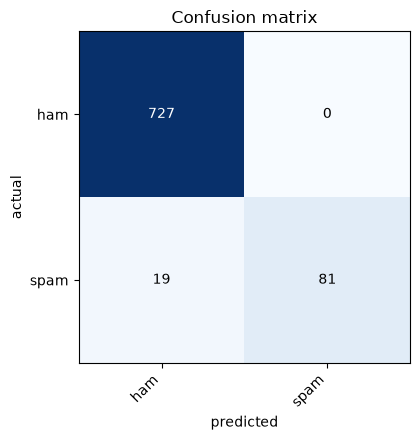

In [4]:
# where the spam classifier goes wrong on the validation set
X_train, X_val, X_test, y_train, y_val, y_test, pre = preprocess_data(sms, "label", text_cols=["message"])
plot_confusion_matrix(y_val, model.predict(X_val), labels=["ham", "spam"])

## 3. KDD Cup 1999: network intrusion category

A random forest with a small randomised search. The raw file has no header and spells labels with
a trailing dot; `prepare_kdd` maps the attack names to five categories.

In [5]:
if RUN_KDD:
    kdd_file = fetch_dataset(KDD_ATTACK_URL, file_name="kddcup.data_10_percent.gz")
    kdd = prepare_kdd(load_csv(kdd_file, header_names=KDD_COLUMNS))
    print(kdd["attack_category"].value_counts())
    model, metrics = run_tabular("kdd", kdd, "attack_category", "random_forest")
else:
    print("RUN_KDD is False; set it to True to run this section")

RUN_KDD is False; set it to True to run this section


## 4. Malimg: malware family from a byte-plot image

A ResNet-50 backbone with a new head, trained for ten epochs.

In [6]:
if RUN_MALIMG:
    folder = fetch_dataset("https://www.kaggle.com/api/v1/datasets/download/ikrambenabd/malimg-original")
    train_loader, test_loader, n_classes, n_channels = load_images(
        folder, image_size=75, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    cnn, history = train_cnn(train_loader, n_classes, n_channels, n_epochs=10)
    plot_training(history)
    accuracy = evaluate_cnn(cnn, test_loader)
    save_model(cnn, metadata={"dataset": "malimg", "accuracy": accuracy}, name="malimg_resnet50")
    log_result("pipeline_walkthrough", dataset="malimg", algorithm="resnet50", accuracy=accuracy)
else:
    print("RUN_MALIMG is False; set it to True to run this section")

RUN_MALIMG is False; set it to True to run this section


## 5. Load a saved model back

Every saved model can be reloaded by name with its preprocessor and metadata.

In [7]:
print(list_models())
model, pre, metadata = load_model("sms_spam_naive_bayes")
print({k: v for k, v in metadata.items() if k != "metrics"})
X = pre.transform(sms.drop(columns="label").head(5))
print("predictions on the first five messages:", list(model.predict(X)))

['LogisticRegression_20260817_231839', 'RandomForestRegressor_20260817_225117', 'diamonds_random_forest_regressor', 'sms_spam_naive_bayes']
{'dataset': 'sms_spam', 'saved_at': '2026-09-23T22:23:38', 'model_class': 'MultinomialNB', 'framework': 'sklearn', 'model_path': '/home/kali/htb-coae/tools & automations/mlops/saved_models/sms_spam_naive_bayes.joblib', 'preprocessor_path': '/home/kali/htb-coae/tools & automations/mlops/saved_models/sms_spam_naive_bayes_preprocessor.joblib'}
predictions on the first five messages: [np.str_('ham'), np.str_('ham'), np.str_('spam'), np.str_('ham'), np.str_('ham')]
